---
title: "Political Bias in News: A Feature-Weighted Classifier"
date: 2024-12-25
subtitle: "DSM140 NLP Coursework: Text Classification"
authors:
  - name: "Johannes Van Cauwenberghe"
    email: "johannes.vc@hotmail.com"
    affiliation: 
      - name: "University of London"
        department: "DSM140 NLP"

format:  
  typst:
    toc: true
    toc-depth: 2
    code-overflow: wrap
    colorlinks: true   
    background-color: transparent

number-sections: true
section-numbering: "I. 1.1.1"

bibliography: "references.bib"
csl: "elsevier-harvard.csl"
link-citations: true
license: "CC BY"
jupyter: "python3"
execute: 
  enabled: false
---


# Introduction

## Domain-Specific Area

The classification of political bias in news media is a pressing challenge in today’s information-driven world. As news consumption increasingly shifts online, concerns about influence of personalised news recommendations grow. Social media platforms and news aggregators, such as Google News and Apple News, have struggled to navigate the balance between providing relevant content and avoiding ideological echo chambers [@helberger2019]. This highlights the pressing need for systematic approaches to detect and understand political bias in journalism.

While the study of "media bias" is well-trodden, natural language processing (NLP) techniques continue to offer novel contributions. A systematic method for identifying political bias can benefit citizens as well as researchers. It can improve transparency in journalism and enable more informed news consumption.

Central to the classification task are textual features such as word choice and frequency. These will serve as markers of political orientation. Building on prior research in text classification, such as @jurafsky2024 and @monroe2017, this project employs a Bayesian approach to feature selection and ranking. Specifically, the Log Odds Ratio (LOR) adjusted with the Informative Dirichlet Prior (IDP). This adjustment accounts for word frequencies in a larger background corpus and smoothes local fluctuations in bias and variance. While implementation details will be covered in @sec-classification, LOR-IDP provides a robust foundation for identifying discriminative features.

This project benefits from the AllSides dataset, which provides a substantial corpus of labelled news headlines categorised by political bias. Complementing this is the NewsCatcher API, with a background corpus as well as a large volume of additional content. Together, these resources enable the development of a sophisticated classifier that combines labelled and unlabelled data to uncover ideological leanings in news content.

## Objectives

The primary goal of this project is to develop a text classifier capable of identifying political bias in news articles. By leveraging a large labelled dataset, the objective is to create a model that significantly outperforms baseline accuracy, achieving at least a 5-10% improvement. To this end, the project will train and evaluate three classic classification algorithms: Naive Bayes, Logistic Regression, and Random Forest.

Furthermore, in Chapter 22, "Lexicons for Sentiment, Affect, and Connotation", @jurafsky2024 sets out several advanced feature selection techniques. This project aims to implement one of these, the Log Odds Ratio Informative Dirichlet Prior (LOR-IDP). As a feature extraction, selection and ranking technique, it complements the Bag-of-Words (BoW) representations outlined in earlier chapters. The method provides a transparent and interpretable selection process. This is hugely beneficial for applications where explanatory descriptions are essential, such as is the case with political bias in media.

Leveraging this word-level insight in what constitutes political bias in news, this project ultimately aims to help inform impartiality rules and their application to the news domain. Stakeholders include publishers as well as aggregation platforms and social media. The ultimate aim is to help bridge divides and differentiate real concerns from tribal politics and divisive rhetoric. This work also aligns with the author’s Final Project on creating balanced news recommendation systems.[^1] Identifying and mitigating divisive language ultimately is of great societal benefit.

[^1]: For reference, the full title reads: "Evaluating Normative Metrics in Transformer-Based News Recommendation Systems"

While this project aims to build a basic binary classifier, future iterations could explore more fine-grained dimensions of political bias. For example, binary 'left' and 'right' classes can be refined into subcategories, such as extreme left, moderate left, centre-left, and so on. Furthermore, topical modelling could allow further refinements such as pro- vs. anti-establishment, as well as economic and social policy dimensions.

The project also investigates the potential for transfer learning---assessing whether a model trained on American data can generalise to UK news. This exploration into transfer learning is to provide insight into the robustness of the feature selection process and the adaptability of the classifier across different cultural and geographical contexts.

To summarise, the project pursues these core objectives:

-   Develop a classifier that categorises news articles as left- or right-leaning.
-   Evaluate the efficacy of LOR-IDP in feature selection for text classification.
-   Compare the performance of Naive Bayes, Logistic Regression, and Random Forest classifiers.
-   Investigate transferability across cultural and linguistic contexts.

Ethical considerations are central to this project, particularly given the nature of political discourse and the potential for encountering sensitive or offensive content in the dataset. To mitigate risks, any content deemed excessively inflammatory or irrelevant to the research objectives will be excluded from the analysis. While acknowledging the possibility of offence, the project prioritises advancing research in media transparency and public discourse over such risks, ensuring that findings are communicated sensitively and responsibly.

## Dataset

The dataset comprises two main components:

1.  **AllSides Dataset**: The AllSides dataset includes 22,000 hand-annotated news headlines and snippets, categorised by political bias as left, right, or centre. Originating from [AllSides](https://www.allsides.com/about), this dataset is curated to expose political bias in how major news stories are covered across ideological spectrums. Political bias labels are determined at the publication level and are accompanied by numerical ratings ranging from -5 to +5. The dataset consists of carefully curated side-by-side comparisons of the coverage on major news stories (as illustrated below).

    ![image](./media/Screenshot%20from%202024-12-30%2007-19-43.png)

    :   Source: [allsides.com](https://www.allsides.com/story/donald-trump-trump-says-he-wants-us-control-panama-canal-greenland-and-canada).

    This data is partly scraped and partly repurposed from previous work by @haak2023. Put together, it ranges from 2022 to today, and consists of headlines and snippets in terms of textual content. Word-length distributions are discussed in @sec-summary-stats. All labelled content is attributed to AllSides under their Creative Commons License, as outlined in their [Terms of Use](https://www.allsides.com/terms-of-use).

    Finally, it should be noted that similar ratings are provided by [Media Bias / Fact Check](https://mediabiasfactcheck.com/) in the US. Side-by-side comparisons in the UK are done (without labels) in The Week (a magazine).

2.  **NewsCatcher API Background Corpus**: To enhance the classifier’s ability to generalise, the NewsCatcher API[^2] provides 10,000 unlabelled news articles from diverse publications. This background corpus is filtered based on "centre"-labelled sources and ranges from 15 to 25th of December 2024, offering a broad and current representation of news content. These are (mostly) full-length articles and will be used for smoothing probabilities in the LOR-IDP approach and addressing sparsity in the labelled dataset. 

    Additionally, 23,000 full-length articles were fetched from NewsCatcher API. Given a disappointing early performance, and the fact that AllSides labels are at the level of each publication, a search query with 'politics' as topic filter and 'October to December' as date range dramatically increased the size and average word count per article, enriching the feature space and addressing class imbalances within the dataset.

[^2]: NewsCatcher Api has sponsored this project with 6000 free API calls. See: [newscatcherapi.com](https://www.newscatcherapi.com/)

Together, the AllSides dataset and NewsCatcher API form a complementary resource set: the AllSides dataset provides high-quality labels for training and testing, while the NewsCatcher corpus offers the contextual background needed for effective feature selection. These datasets also allow us to evaluate the generalisability of the classifier, including its application to UK publications.

## Evaluation Methodology

Given efforts to balance the dataset, accuracy will serve as the primary metric for evaluating the classifier’s overall performance. Precision and recall scores will also be examined to assess how well the model manages the trade-offs between the two.

Throughout the project we will focus on identifying systematic errors in "falsely predicted 'left' articles" and "falsely predicted 'right' articles." Adopting the iterative methodology outlined in @bird2009, we will focus on the evaluation of feature ranking. This will ensure that discriminative features are effectively identified and optimally weighted. As demonstrated below in its implementation, the classifier will be evaluated and fine-tuned using a cycle of feature extraction, error analysis, and refinement. Misclassified samples will be analysed to trace errors back to the feature selection process.

For instance, recurring errors may lead to the inclusion of additional stopwords or highlight issues with the scaling factor ($\alpha_0$). In particular, as we will see below, the evaluation of class imbalance will eventually lead to fetching supplementary data.

For parameter selection, cross-validation will be employed. This ensures that the model generalises effectively without repeatedly probing the test set with different parameter sets, inadvertently exposing the unseen data to the model's hyperparameters.

Furthermore, the evaluation will include an assessment of the classifier's generalisability. We will investigate the extent to which the model trained on a predominantly American dataset can effectively classify political bias in UK publications. 


---

# Implementation 

The notebook can organised in two parts:

-   In @sec-Preparation the data is collected and prepared (combining a csv-file, a scrape, and an API call),
-   In part two we pre-process this data and model it for predictions.

It is organised so that it can be run from @sec-Preprocessing onwards – granted all dependencies are installed.

## Imports

In [1118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.text import TextPath
from scipy.sparse import hstack, csr_matrix
import seaborn as sns

# Standard library
from tqdm.notebook import tqdm, trange
from collections import Counter
from urllib.parse import urlparse
import re, random, asyncio, os, string
from multiprocessing import Pool
from IPython.display import Markdown
from typing import Literal

# Scraping tools
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.common.exceptions import *
from fake_useragent import UserAgent

# Api
from newscatcherapi import NewsCatcherApiClient

# NLP Packages
import nltk
from nltk.corpus import stopwords 
from nltk.text import Text
from nltk import pos_tag, word_tokenize

# ML Packages
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (ConfusionMatrixDisplay, 
                             accuracy_score, 
                             classification_report)

# Global settings
tqdm.pandas()
np.random.seed(42)
plt.rcParams['text.usetex'] = True
pd.options.display.max_colwidth = 80


## Data Preparation {#sec-Preparation}

We will now collect and prepare the datasets. We first repurpose the dataset from $Q_{bias}$.[^3] Next, we will extend it with a crawl of AllSides website with updated data as well as a numerical rating, from extreme left to extreme right on a scale from -5 to +5. Finally, we will prepare an unlabelled dataset as a background corpus.

[^3]: @haak2023 analyse media bias in search queries and query suggestions. The authors fine-tuned a generative model in an experiment to reproduce political bias. This is an objective very different from our own. Available here https://github.com/irgroup/Qbias

### $Q_{Bias}$ dataset

We begin the preparation simply by loading the existing scrape of the AllSides headline-roundups.

In [1119]:
#| tbl-colwidths: [15,25,55,10]

# The existing scrape of the AllSides headline-roundups
Q_bias_df = pd.read_csv('./allsides_balanced_news_headlines-texts.csv', 
                        index_col=0)
Q_bias_df = Q_bias_df[['source', 'heading', 'text', 'bias_rating']]
Q_bias_df.set_index('source').head()

,heading,text,bias_rating
source,,,
New York Times (News),Chicago Gun Violence Spikes and Increasingly Finds the Youngest Victims,As Yasmin Miller drove home from a laundromat in Chicago’s Englewood neighbo...,left
Chicago Tribune,‘Bullets just came from nowhere’: Fourth of July weekend gun violence kills ...,As many Chicagoans were celebrating the Fourth of July with barbecues and af...,center
New York Post (News),Dozens of shootings across US mark bloody July 4th weekend,The nation’s 4th of July weekend was marred by the wrong kind of fireworks.\...,right
The Epoch Times,Federal Government Will Run Out of Cash on Oct. 18 If Debt Ceiling Isn’t Rai...,Treasury Secretary Janet Yellen on Tuesday warned members of Congress that t...,right
Washington Post,Yellen tells Congress that U.S. will run out of debt ceiling flexibility on ...,Treasury Secretary Janet Yellen on Tuesday told Congress that the U.S. will ...,left


### Crawl data

As news is a rapidly changing medium, it is justified to extend the dataset with up-to-date news and labels.

In [34]:
ua = UserAgent()

def get_selenium_driver(): 
    """Returns the driver"""

    # Run in background 
    chrome_options = Options()
    chrome_options.add_argument("--headless") # Uncomment this for insight

    # Rotate user-agents
    chrome_options.add_argument(f"user-agent={ua.random}")
    return webdriver.Chrome(service=Service('/usr/bin/chromedriver'), options=chrome_options)

In [37]:
# retrieve number of pages 
# using the pager button at the bottom
driver = get_selenium_driver()
driver.get('https://www.allsides.com/headline-roundups')
url_to_last_page = driver.find_element(By.CLASS_NAME, "pager-last").find_element(By.TAG_NAME, "a").get_attribute("href")
last_page_index = int(url_to_last_page.split('=')[-1])
last_page_index

202

In [ ]:
# retrieve links
links = []
for page in trange(1, last_page_index + 1):
    driver.get("https://www.allsides.com/headline-roundups?page=" + str(page)) 
    main_table = driver.find_element(By.TAG_NAME, "tbody")
    rows = main_table.find_elements(By.TAG_NAME, "tr")
    for i in rows:
        entry = i.find_elements(By.TAG_NAME, "td")
        link = entry[0].find_element(By.TAG_NAME, "a")
        links.append(link.get_attribute("href"))

100%|██████████| 201/201 [08:22<00:00,  2.50s/it]


In [ ]:
# Save links as csv
with open("allsides_links.csv", "w") as f:
    for line in links:
        print(line, file=f)

In [17]:
# Scraper function for multi-threaded scraping
def scraper(from_idx, to_idx):
    driver = get_selenium_driver()
    
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, 'body')))    
    articles = []
    for link in tqdm(links[from_idx:to_idx]):
        
        driver.get(link)
        try:
            timestamp = driver.find_element(By.CLASS_NAME, "date-display-single").get_attribute('content')
        except Exception as e:
            # print(e.msg)
            continue

        for news in driver.find_elements(By.CLASS_NAME, "news-item"):
            # only the 3 first `news-items` have the following tags
            # we try until we find a NoSuchElementException
            try:
                bias = news.find_element(By.TAG_NAME, "h3").get_attribute('class') 
                source = news.find_element(By.TAG_NAME, "a").get_attribute("href")
                
                title = news.find_element(By.TAG_NAME, "a").text
                snippet = news.find_element(By.CLASS_NAME, "body-contents").text
                link_to_score = news.find_element(By.CLASS_NAME, "source-area").get_attribute('href')

                articles.append({"title": title, 
                                "snippet": snippet, 
                                "bias": bias, 
                                "bias_score": link_to_score, 
                                "date": timestamp, 
                                "url": link, 
                                "source": source})
                
            except NoSuchElementException as e:
                # print(e.msg)
                continue
    return articles

In [ ]:
# Execute crawl (this takes some time)
# (Use multiple threads to allow for waiting in each thread)
batch_size = 500
future = asyncio.gather(*[asyncio.create_task(
    asyncio.to_thread(scraper, batch, batch+batch_size)) 
    for batch in range(1, len(links), batch_size)])

driver.close()

In [ ]:
# Save results
flattened = [res for fut in future.result() for res in fut]
allsides_updated = pd.DataFrame(flattened)

# allsides_updated.to_csv("allsides_updated.csv")

### Scrape Numerical Ratings

We add the numerical ratings as a column. These originate from AllSides 'news-source' profiles. Whereas the Headline Roundups give 'left' and 'right' labels, for the numerical ratings we need to scrape the profile pages. Here, only sources with more than 2 articles are scraped.

In [217]:
# Focus on common sources (with more than two articles)
sources = allsides_updated.bias_score.value_counts()
sources_idx = sources[sources > 2].index
source_list = list(sources_idx)
len(source_list)

187

In [27]:
#| tbl-colwidths: [25,55,25]

# Lookup table for ratings
numerical_ratings_scrape = []
for url in tqdm(source_list[128:]):
    driver.get(url)
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, 'body')))
    try:
        numerical_ratings_scrape.append({
            'bias_score': url,
            'source': driver.find_element(By.TAG_NAME, "h1").text,
            'num_rating': driver.find_element(By.CLASS_NAME, "numerical-bias-rating").text})
    except NoSuchElementException as e:
        print(e.msg, url)

lookup = pd.DataFrame(numerical_ratings_scrape)
lookup.to_csv('rating_lookup.csv')
lookup.set_index('source').head()

,bias_score,numerical_rating
source,,
Fox News Digital,https://www.allsides.com/news-source/fox-news-...,3.88
CNN Digital,https://www.allsides.com/news-source/cnn-media...,-1.30
New York Times (News),https://www.allsides.com/news-source/new-york-...,-2.20
Washington Post,https://www.allsides.com/news-source/washingto...,-2.20
The Hill,https://www.allsides.com/news-source/hill-medi...,-0.80


In [20]:
# Saved here
lookup = pd.read_csv('rating_lookup.csv')

In [306]:
# Use lookup to add ``numerical_rating`` column
Q_bias_df_joined = Q_bias_df.join(lookup, on='source')

# Our main df also missed the ``source`` column
# This will be useful for concatenation later on
df_joined = allsides_updated.join(lookup.reset_index().set_index('bias_score'), on='bias_score', lsuffix='_l')

# FYI, our lookup contains many UK newspapers
all(uk_paper in lookup.index for uk_paper 
    in ['BBC News' ,'The Economist', 'Daily Mail'])

True

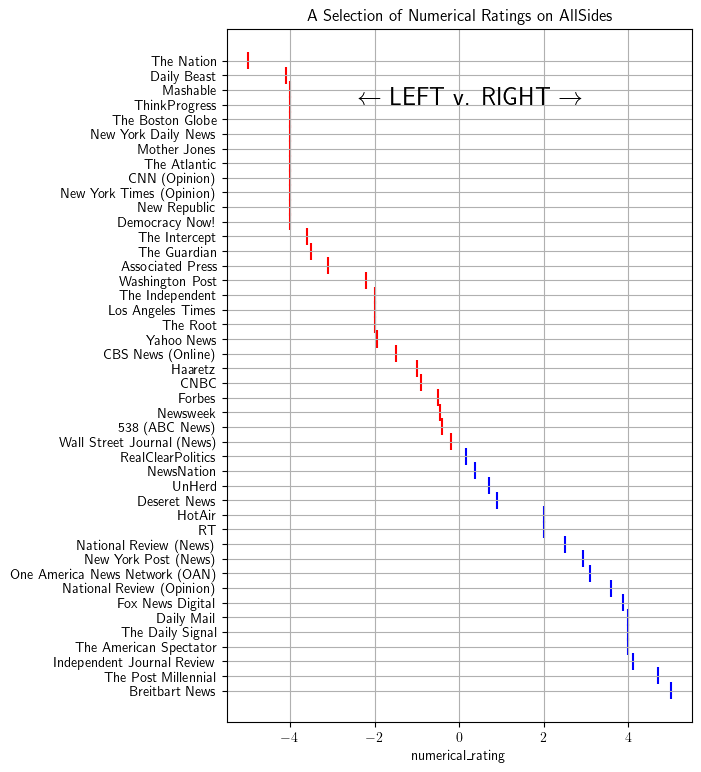

In [ ]:
#| fig-cap: "Numerical Ratings on AllSides" 

# Brief inspection
lookup_viz = lookup.sort_values('numerical_rating', ascending=False).dropna()
lookup_viz = lookup_viz[lookup_viz.index % 3 == 0]

# Plot
ax = lookup_viz.plot.scatter(x='num_rating', 
                        y='source', 
                        marker='|', 
                        s=150, 
                        c=['b' if b > 0 else 'r' for b in lookup_viz.num_rating],
                        figsize=(6, 9),
                        title='A Selection of Numerical Ratings on AllSides',
                        ylabel='',
                        )

ax.grid(visible=True, which='major')
ax.text(x=-2.4, y=40, s=r'$\leftarrow$  LEFT  v.   RIGHT $\rightarrow$', fontsize=18)
# ax.
plt.show()

### NewsCatcher API Dataset

#### Background data

Log-odds informative dirichlet prior relies on a vast background corpus. The prior word frequencies serve as a snoothing to help differentiate the politically biased news from the center. To achieve this, the 'center' headlines and snippets from AllSides are extended with a corpus of full-length articles obtained using the NewsCatcher API. 10,000 articles are fetched from publications labelled 'center' by AllSides. However, whereas the $Q_{bias}$ dataset contains the `sources` in plain text, NewsCatcher expects a url of the shape *wired.com*. This requires some parsing of source names. 

In [ ]:
newscatcherapi = NewsCatcherApiClient(
    x_api_key=os.getenv('NEWSCATCHER_API_KEY'))

In [ ]:
# Extract center `sources`
def parse_source(bias='center'):
    parsed_sources = df_joined[df_joined.bias == bias].source.dropna().unique()
    parsed_sources_df = pd.DataFrame(parsed_sources, columns=['source'])

    # Prepare a list of sources of the shape `wired.com`
    parsed_sources_df = (parsed_sources_df
                    
                    # Filter using a join
                    .join(df_joined.set_index('source'), on='source') 
                    .drop_duplicates(subset='source')

                    # Parse `source_l` links 
                    .source_l
                    .map(lambda x: urlparse(x).netloc.replace('www.', '') if isinstance(x,str) else ''))

    # Remove duplicates and NaNs, and return
    return list({c for c in parsed_sources_df if c})

# Inspect all sources (long list)
center_sources = parse_source(bias='center')
center_sources
# -> Too long to print

# Selected sources (redacted)
center_sources = ['wired.com', 'cnbc.com', 'euronews.com', 'dw.com', 'bbc.com', 'fortune.com', 'thedispatch.com', 'allsides.com', 'pewresearch.org', 'cnet.com', 'wsj.com', 'csmonitor.com', 'realclearinvestigations.com', 'techcrunch.com', 'ft.com', 'forbes.com', 'thehill.com', 'thedailybeast.com', 'washingtonpost.com', 'newsweek.com', 'unherd.com', 'reuters.com', 'qz.com', 'factcheck.org']

# Fetch API call (recursively)
all_articles = newscatcherapi.get_search_all_pages(
                                         q='*',
                                         from_='10 days ago',  
                                         topic='politics',
                                         lang='en',
                                         sources=center_sources)

print(all_articles['total_hits']) # 10,000

# Save
# pd.DataFrame(all_articles['articles']).to_csv('background_articles.csv', index=False)

#### Merge the $Q_{bias}$ data with the Crawl Data

In [311]:
# Selecting columns for concatenation
df_joined = df_joined[['title', 'snippet', 'bias', 'date', 'url', 'source_l', 'source', 'numerical_rating']]

# Renaming columns for concatenation
Q_bias_df_joined.columns = Q_bias_df_joined.columns.map(
    {'heading': 'title', 
    'source': 'source', 
    'text': 'snippet', 
    'bias_rating': 'bias',
    'bias_score': 'bias_score',
    'numerical_rating':'num_rating'})

# Selecting columns for concatenation
Q_bias_df_joined = Q_bias_df_joined[['title', 'source', 'snippet', 'bias', 'num_rating']]

# Execute concat and clean up overlap
pd.concat([df_joined, Q_bias_df_joined]).drop_duplicates(subset='title', keep='first').to_csv('allsides_combined.csv', index=False)

allsides_combined = pd.read_csv('allsides_combined.csv')
allsides_combined.dropna(subset=['title', 'bias', 'numerical_rating'], inplace=True)

print(f'We now have {allsides_combined.shape[0]} labeled news articles.')

We now have 22101 labeled news articles.


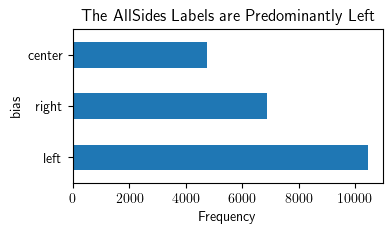

In [1071]:
#| label: fig-imbalance
#| fig-cap: "Visualising class imbalance in the combined AllSides dataset" 

allsides_combined.bias.value_counts().plot.barh(title='The AllSides Labels are Predominantly Left', xlabel='Frequency', figsize=(4,2))
plt.show()

#### Rebalance and More Data

Given the class imbalance we saw in @fig-imbalance, we add 3000 'politics' articles from publications labelled 'right' by AllSides. Futhermore, we also add 10,000 articles of 'left' and 'right' sources respectively.  

In [ ]:
right_sources = parse_source(bias='right')

# Fetch API call (recursively)
all_articles = newscatcherapi.get_search_all_pages(q='*',
                                         from_='3 months ago',  
                                         topic='politics',
                                         lang='en',
                                         sources=right_sources,
                                        #  max_page=30  # We added another 3,000 to rebalance
                                         )
pd.DataFrame(all_articles['articles']).to_csv('right_articles.csv', index=False)

In [141]:
# A sample of sources
right_sources[:10]

['freebeacon.com',
 'justthenews.com',
 'zerohedge.com',
 'wsj.com',
 'newsmax.com',
 'nypost.com',
 'dailymail.co.uk',
 'washingtontimes.com',
 'telegraph.co.uk',
 'hotair.com']

In [ ]:
left_sources = parse_source(bias='left')

all_articles = newscatcherapi.get_search_all_pages(q='*',
                                         from_='3 months ago',  
                                         topic='politics',
                                         lang='en',
                                         sources=left_sources,                               
                                         )
pd.DataFrame(all_articles['articles']).to_csv('left_articles.csv', index=False)

In [142]:
left_sources[:10]

['theroot.com',
 'mashable.com',
 'lgbtqnation.com',
 'usnews.com',
 'slate.com',
 'miamiherald.com',
 'bostonglobe.com',
 'economist.com',
 'theguardian.com',
 'theverge.com']

In [88]:
# Label the articles with a bias label, and concatenate them.
df_left = pd.read_csv('left_articles.csv')
df_left['bias'] = 'left'
df_right = pd.read_csv('right_articles.csv')
df_right['bias'] = 'right'

# Combine and prepare for lookup
df_comb = pd.concat([df_left, df_right])
df_comb.drop_duplicates(subset='title', inplace=True)
df_comb.dropna(subset='title', inplace=True)
df_comb.rename(columns={'excerpt':'snippet', 
                        'clean_url': 'source_api'}, inplace=True) 
df_comb.shape

(21407, 20)

In [ ]:
# Add the AllSides' `numerical_rating` to the NewsCatcher articles
allsides_combined['source_api'] = allsides_combined\
    .source_l\
        .map(lambda x: urlparse(x).netloc.replace('www.', '') if isinstance(x,str) else '')

# Create a new lookup table based on the
lookup = allsides_combined[['numerical_rating', 'source_api']]
lookup = lookup.drop_duplicates('source_api').dropna(subset='source_api') #.set_index('source_api')

# Join `numerical_rating` and save
df_comb_ = df_comb.join(lookup.set_index('source_api'), on='source_api')
df_comb_.to_csv('rebalance_and_added.csv')

### Summary Statistics {#sec-summary-stats}

#### Summary of the Labelled Data

In [733]:
# Load biased data into `AllSides_df` dataframe
AllSides_df = pd.read_csv('allsides_combined.csv', usecols=['title', 'snippet', 'bias', 'numerical_rating', 'source_l'])
AllSides_df['source_api'] = AllSides_df.source_l\
        .map(lambda x: urlparse(x).netloc.replace('www.', '') if isinstance(x,str) else '')
AllSides_df.dropna(subset=['title', 'bias', 'numerical_rating'], inplace=True)
AllSides_df.rename(columns=dict(numerical_rating='num_rating'), inplace=True)
AllSides_df = AllSides_df[AllSides_df.bias != 'center']

# Extend the AllSides dataset and concat
more_articles = pd.read_csv('rebalance_and_added.csv', usecols=['title', 'snippet', 'summary', 'bias', 'numerical_rating', 'source_api'])
more_articles.dropna(subset=['title', 'bias', 'numerical_rating'], inplace=True)
more_articles.rename(columns=dict(numerical_rating='num_rating'), inplace=True)
AllSides_df = pd.concat([AllSides_df, more_articles])

In [724]:
# Distribution of lengths or article titles and snippets

AllSides_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38756 entries, 0 to 21406
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       38756 non-null  object 
 1   snippet     38669 non-null  object 
 2   bias        38756 non-null  object 
 3   source_l    10907 non-null  object 
 4   num_rating  38756 non-null  float64
 5   source_api  38756 non-null  object 
 6   summary     21407 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.4+ MB


The 38756 labelled articles contain on average 3800.0 words; the median is around 3000.0.


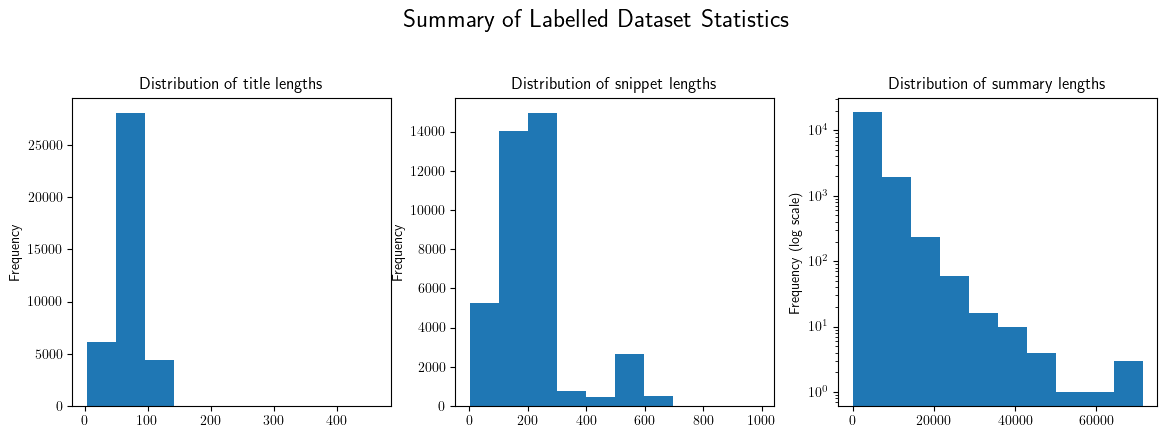

In [1069]:
#| fig-cap: "Distribution of lengths or article titles, excerpts, and summaries - these summaries are much longer than the snippets and excerpts, hence the log scale."

_, axs = plt.subplots(1,3, figsize=(14,4))
AllSides_df.title.str.len().plot.hist(ax=axs[0], title='Distribution of title lengths')
AllSides_df.snippet.str.len().plot.hist(ax=axs[1], title='Distribution of snippet lengths')
AllSides_df.summary.str.len().plot.hist(ax=axs[2], 
                               title='Distribution of summary lengths', 
                               ylabel='Frequency (log scale)',
                               logy=True)

print(f'The {AllSides_df.shape[0]} labelled articles contain on average {round(AllSides_df.summary.str.len().mean(), -2)} words; the median is around {round(AllSides_df.summary.str.len().median(), -2)}.')
plt.suptitle('Summary of Labelled Dataset Statistics', fontsize=18, y=1.1)
plt.show()

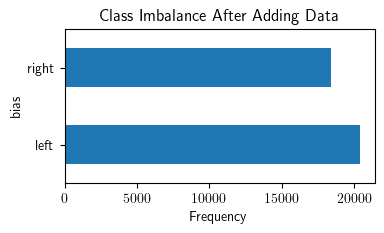

In [1070]:
#| label: fig-imbalancev2
#| fig-cap: "The class imbalance is largely mitigated after adding data" 

AllSides_df.bias.value_counts().plot.barh(title='Class Imbalance After Adding Data', xlabel='Frequency', figsize=(4,2))
plt.show()

In [345]:
# The 'left' and 'right' article are of similar lengths
sent_lens = (AllSides_df.title.fillna('').str.split() + 
             AllSides_df.snippet.fillna('').str.split() + 
             AllSides_df.summary.fillna('').str.split())\
                .map(lambda x: len(x))

sent_lens[AllSides_df.bias == 'left'].mean(), sent_lens[AllSides_df.bias == 'right'].mean()

(401.3508290002943, 377.2154599891127)

#### Summary of the Background Data

In [ ]:
# Load and preprocess background data (from NewsCatcher API)
bg_df = pd.read_csv('background_articles.csv', usecols=['title', 'excerpt', 'summary'])
bg_df.drop_duplicates(subset='title', inplace=True)
bg_df.dropna(subset='title', inplace=True)
bg_df.rename(columns={'excerpt':'snippet'}, inplace=True) 

# Append `center`-labeled data from AllSides
AllSides_bg = AllSides_df[AllSides_df.bias == 'center']
bg_all = pd.concat([bg_df, AllSides_bg]) 
assert bg_all.duplicated().sum() == 0

The 8191 background articles contain on average 2700.0 words; the median is 1800.0.


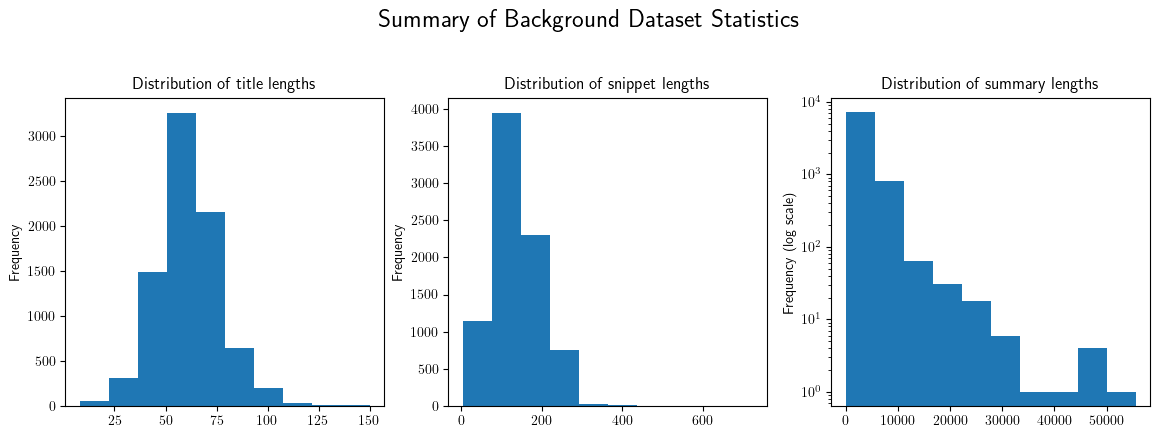

In [338]:
#| fig-cap: "Distribution of lengths or article titles, excerpts, and summaries - these summaries are much longer than the snippets and excerpts, hence the log scale."

_, axs = plt.subplots(1,3, figsize=(14,4))
bg_df.title.str.len().plot.hist(ax=axs[0], title='Distribution of title lengths')
bg_df.snippet.str.len().plot.hist(ax=axs[1], title='Distribution of snippet lengths')
bg_df.summary.str.len().plot.hist(ax=axs[2], 
                               title='Distribution of summary lengths', 
                               ylabel='Frequency (log scale)',
                               logy=True)

print(f'The {bg_df.shape[0]} background articles contain on average {round(bg_df.summary.str.len().mean(), -2)} words; the median is {round(bg_df.summary.str.len().median(), -2)}.')
plt.suptitle('Summary of Background Dataset Statistics', fontsize=18, y=1.1)
plt.show()


---

## Preprocessing  {#sec-Preprocessing}

Preprocessing is a critical step to transform raw textual data into a format for classification. As we saw in @fig-imbalance, there was some class imbalance. Fortunately, we obtained additional data, which will have a noticable impact on the performance of our classifiers. To enable us to reuse the preprocessing pipeline with varying features, we will contain the steps in a function called `apply_preprocessing()`.

The following steps will be applied:

- **Tokenisation**: Breaking down articles and headlines into individual words.
- **Lowercasing**: Ensuring uniformity by converting all text to lowercase.
- **Stopword Removal**: Filtering out common words (e.g., “and”, “the”) that do not contribute meaningfully to classification.
- **Lemmatisation**: Reducing words to their base forms (e.g., “running” to “run”) to standardise vocabulary.

Core datasets are stored in CSV format, with each row representing an article and its corresponding *AllSides* label.The preprocessed text fields are populated in the first steps of preprocessing.

### Preprocessing as a Function

We begin by specifying the preprocessing functionality in a modular and easily reproduceable fashion.

In [732]:
from nltk.corpus import stopwords
# Stopwords (nltk.download('stopwords'))

stop_words = stopwords.words('english') + \
    list(string.punctuation + "’”“`'—") + \
        ["'d", "'ll", "'re", "'s", "'ve", 'could', 
         'might', 'must', "n't", 'nt', 'need', 
         'sha', 'wo', 'would', '``', '...']

# Lemmatiser
wn_lem = nltk.WordNetLemmatizer()

def apply_preprocessing(sent):
    
    # Replace em dash with space
    sent = sent.replace('—', ' ')  

    # Tokenize and return pos_tags
    token_sent = []    
    for word,tag in pos_tag(word_tokenize(sent)):
        
        # Filter out non-ascii characters
        word = ''.join(char.lower() for char in word if char in string.ascii_letters)         

        # Filter stopwords   
        if word and word.lower() not in stop_words:       
            
            # Lemmatise based on tag
            if tag[0] in ['A','N','V']:

                # print(word,tag[0])
                token_sent.append(wn_lem.lemmatize(word,tag[0].lower()))
                
            else: 
                token_sent.append(wn_lem.lemmatize(word))
    return token_sent

### Implementing the Preprocessing


***Edit:***  We must remove the noisy features discovered in @sec-feature-importance. These were:
```py
['width', 'byline', 'maxwidthpx', 'px', 'marginleft', 'marginright']
```

In [737]:
# First remove some bad scrapes with html tags in the text
pattern = r'max-?widthpx|margin-?left|margin-?right'

mask = AllSides_df.summary.fillna('').str.contains(pattern, case=False, regex=True)
AllSides_df.loc[mask, 'summary'] = ''

In [738]:
# Construct X and y for baseline
AllSides_df['sents'] = AllSides_df.title + ' ' + AllSides_df.snippet.fillna('') + ' ' + AllSides_df.summary.str[:10000].fillna('')

In [739]:
AllSides_df['pre_sents'] = AllSides_df.sents.progress_apply(apply_preprocessing)
labels = AllSides_df.bias

assert AllSides_df.sents.isna().sum() == 0
assert len(labels) == len(AllSides_df.pre_sents), 'labels and data are not aligned'

  0%|          | 0/38756 [00:00<?, ?it/s]

In [742]:
# Unique words in extend AllSides dataset
unique_words = {pre for row in AllSides_df.pre_sents for pre in row}
len(unique_words)

104181

In [348]:
# Concat strings and truncate summary to 1000 chars
bg_all['sents'] = bg_all.title + ' ' + bg_df.snippet.fillna(' ') + ' ' + bg_df.summary.str[:10000].fillna(' ')
bg_all['pre_sents'] = bg_all.sents.progress_apply(apply_preprocessing)

  0%|          | 0/8191 [00:00<?, ?it/s]

In [349]:
# Unique words in background dataset
unique_bg = {pre for row in bg_all.pre_sents for pre in row}
len(unique_bg)

82208

**Inspect sample**

In [743]:
# Print example
for l, b in zip(labels[:2], AllSides_df.pre_sents[:2]):
    print(l)
    print(b)

left
['social', 'security', 'fairness', 'act', 'restore', 'benefit', 'million', 'policy', 'still', 'cause', 'hardship', 'year', 'old', 'evelyn', 'paternostro', 'spend', 'day', 'work', 'part', 'time', 'cashier', 'dollar', 'tree', 'decade', 'dedicate', 'life', 'education', 'serve', 'teacher', 'principal', 'louisiana', 'despite', 'year', 'public', 'service', 'struggle', 'make', 'end', 'meet']
right
['washington', 'giveaway', 'government', 'worker', 'congress', 'rend', 'government', 'funding', 'deadline', 'entire', 'political', 'press', 'focus', 'spectacle', 'lawmaker', 'pass', 'different', 'bill', 'communicate', 'fundamental', 'unseriousness', 'elect', 'leader', 'approach', 'government', 'spending']


**Type-Token Ratio**  

An indicator of preprocessing success, here we show `all_tokens` vs `unique tokens`. A low type-token ratio (TTR) indicates a high reuse of words. 

In [351]:
# Type-Token Ratio (TTR)
all_tokens = [pre for row in AllSides_df.pre_sents for pre in row]
ttr = round(len(set(all_tokens))/len(all_tokens), 3)
assert '' not in all_tokens
print(f"The total tokens are {len(all_tokens)}, \n\
the unique tokens are {len(set(all_tokens))}, \n\
      -> TTR = {ttr}")

The total tokens are 8251278, 
the unique tokens are 104455, 
      -> TTR = 0.013


### Train-Test Split

To ensure a robust evaluation of the classifier, the data is split into training and test sets. This ensuring that the classifier does not have access to the test labels during training, thereby maintaining the integrity of the evaluation process.

In [744]:
X_train, X_test, y_train, y_test = train_test_split(AllSides_df,  # before preprocessing
                                                    labels, 
                                                    test_size=0.1,
                                                    random_state=123)

X_train.sents.shape, X_test.sents.shape

((34880,), (3876,))



------------------------------------------------------------------------

## Baseline Performance

The literature contains various candidates for a baseline. @hajare trained a model on political speeches in US congress and predicted political bias on social media platforms based on the word features. The authors achieve a top accuracy of 70.5% and 65.1% in Twitter and Gab data respectively. 

@dalonzo2022 extracted phrases for news media to predict political bias on a topic-by-topic basis. While no concrete figures are presented, a visual comparison with the AllSides classification suggests that there is significant variability across topics. Other sources present better figures (e.g. [here](https://medium.com/@danilo.najkov/detecting-political-bias-in-online-articles-using-nlp-and-classification-models-c1a40ec3989b)) but lack details on the dataset used.

For a simple, non-ML baseline, we will predict the majority label. Next, we will train a Naive Bayes classifier on raw word counts using Bag-of-Words (BOW). This provides a simple yet effective benchmark. 

Performance metrics for this baseline includes a confusion matrix, showing the False Positives and False Negatives in a way that benefits insight and iterative refinenents. These results serve as a benchmark for evaluating improvements achieved through algorithms like Logistic Regression and Random Forest.

### A Simple non-ML Baseline

For a simple analytical baseline, we predict the majority label:

In [745]:
# Predict the majority label
top_label = y_train.value_counts().idxmax()
(y_test == top_label).mean()

0.5255417956656346

### A Basic Model

We now train a simple classifier on raw word counts. Naive Bayes is a competent parametric model, widely used for text classification tasks.

In [746]:
count_vectorizer = CountVectorizer(tokenizer=apply_preprocessing,   # Preprocessing is reapplied here
                                   token_pattern=None, max_features=10000)

base_train = count_vectorizer.fit_transform(X_train.sents)
base_test = count_vectorizer.transform(X_test.sents)

Baseline accuracy: 0.7169762641898865


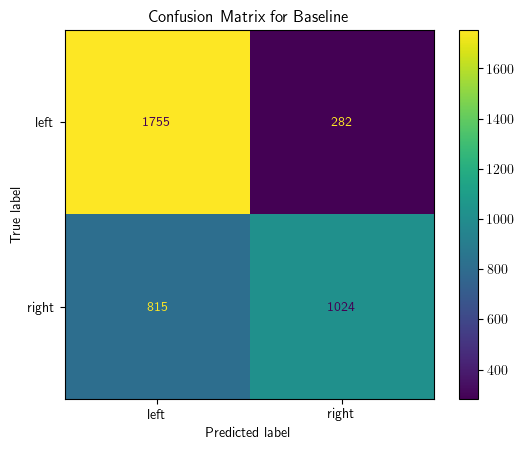

In [747]:
#| fig-cap: "Confusion Matrix for Baseline"

# Train model
model = BernoulliNB()
model.fit(base_train, y_train)

# Predict and print accuracy
base_pred = model.predict(base_test)
print("Baseline accuracy:", accuracy_score(y_test, base_pred))

# Plot Confusion Matrix
cmd = ConfusionMatrixDisplay.from_estimator(model, base_test, y_test, cmap='viridis')
cmd.ax_.set_title('Confusion Matrix for Baseline')
plt.show()


------------------------------------------------------------------------

## Classification {#sec-classification}

The classification section of this project is structured to guide the reader through the essential steps of feature extraction and selection, model training, and evaluation. It begins with an in-depth exploration of the **Log Odds Ratio with Informative Dirichlet Prior (LOR-IDP)** method, highlighting its use in identifying and ranking informative features. The next section focuses on **Training the Classifier**, where three classic models—Naive Bayes, Logistic Regression, and Random Forest—are compared. A range of feature extraction approaches, including TF-IDF, is discussed, alongside the optimisation of feature sets and scaling factors to enhance performance. Finally, the **Evaluating Feature Importance** section delves into how different classifiers interpret and utilise features, with a specific emphasis on understanding feature importance in Naive Bayes and Random Forest. This iterative process integrates error analysis to identify and address weaknesses in the model. 

### Using LOR-IDP to Determine Informative Features

For the feature representation we will use a Bag-of-Words (BoW) approach with LOR-IDP for feature weighting. LOR-IDP will select words with high discriminative power (based on LOR scores) as features.

The **Log Odds Ratio (LOR)** quantifies the likelihood of a word $w$ being more associated with one class compared to another. It is defined as [@jurafsky2024, p.494]:

$$
\text{LOR}(w, c_{left}) = \log \left( \frac{P(w|c_{left})}{(1 - P(w|c_{left}))} \right) - \log \left( \frac{P(w|c_{right})}{(1 - P(w|c_{right}))} \right)
$$

This gives a measure of how much more likely a word is to appear in class $c_{left}$ compared to other classes.

To make LOR robust to small sample sizes, we apply the **Informative Dirichlet Prior (IDP)**, resulting in the adjusted log odds ratio: 

$$
\delta_w^{(i-j)} = \log\left(\frac{f_w^i + \alpha_w}{n^i + \alpha_0 - (f_w^i + \alpha_w)}\right) - \log\left(\frac{f_w^j + \alpha_w}{n^j + \alpha_0 - (f_w^j + \alpha_w)}\right)
$$

Here: 

- $f_w^i$: The raw count of word $w$ in corpus $i$ (e.g., left-leaning articles). 
- $n^i$: The total size (token count) of corpus $i$. 
- $\alpha_w$: The scaled count of word $w$ in the background corpus, derived from $P(w|\text{bg})$. 
- $\alpha_0$: The total scaled size of the background corpus, providing proper smoothing.[^4]

[^4]: @kornraphop2020 suggests to take the union of all features for in the absense of a background corpus.

This gives a measure of how much more frequent $w$ is in corpus $i$ compared to $j$, adjusted for both the background corpus and the relative sizes of $i$ and $j$.

#### Implementating the Feature Selection Method

We are now ready to implement the feature extraction technique. We will document this process step by step:

1.  **The word count per class,**  $f_w^i$.

    To calculate $f_w^i$ for each class, we write a function `freq_word_c()` that takes the `bias` as an argument and returns a `Counter` object.

In [748]:
# Compute frequency of each word in the chosen class.
preprocessed_left = X_train.query("bias == 'left'").pre_sents
preprocessed_right = X_train.query("bias == 'right'").pre_sents

freq_left = Counter([pre for row in preprocessed_left for pre in row])
freq_right = Counter([pre for row in preprocessed_right for pre in row])

2. **The total word count for each class, $n^i$.** 
   
   To calculate the total word count for each class, $n_{left}$ and $n_{right}$, we call the `total()` method an the `Counter` object.

In [749]:
# total word count in each class corpus (n_i and n_j)
n_left = freq_left.total()
n_right = freq_right.total()

n_left, n_right

(3866201, 3455440)

3. **The total word count in the background dataset,** $\alpha_0$.

In [750]:
# Using the preprocessed background text in `bg_all`
alpha = Counter(row for pre in bg_all.pre_sents for row in pre)

In [818]:
# Lower the effect of the prior to reduce the background scaling
alpha_0 = alpha.total() * 1  # Scaling factor

4. **The word frequency in the background corpus, $\alpha_w$.**  
   This will serve as the prior probabilities for each words. First, we normalise $P(w|bg)$. Then, we multply $P(w|bg)$ by its total.

In [819]:
# Normalise P(w|bg)
P_bg = {word: count / sum(alpha.values()) for word, count in alpha.items()}

# Calculate alpha_w using scaled alpha_0
alpha_w = {word: P_bg[word] * alpha_0 for word in alpha}

# Inspect prior probabilities 
pd.Series(alpha_w).sort_values(ascending=False, key=abs).head(10)

say     23011.0
year    11369.0
new     10363.0
make     8334.0
one      8055.0
also     7401.0
u        7074.0
time     6588.0
game     6532.0
go       6130.0
dtype: float64

5. **The $\delta_w^{(i-j)}$ formula:**  
   Finally, we can insert the variables and calculate the delta values for each word. 
   
   Using the formula given in [@jurafsky2024, p. 494], transcribed here:
    $$
    \delta_w^{(i-j)} = \log\left(\frac{f_w^i + \alpha_w}{n^i + \alpha_0 - (f_w^i + \alpha_w)}\right) - \log\left(\frac{f_w^j + \alpha_w}{n^j + \alpha_0 - (f_w^j + \alpha_w)}\right)
    $$
    
    We can write the following function:

In [820]:
def delta_w(freq_w_i, freq_w_j, n_i, n_j, alpha_w, alpha_0):

    # Numerator and denominator for class j
    num_i = freq_w_i + alpha_w
    denom_i = n_i + alpha_0 - num_i

    # Idem for class j
    num_j = freq_w_j + alpha_w
    denom_j = n_j + alpha_0 - num_j

    # logs
    log_i = np.log(num_i / denom_i)
    log_j = np.log(num_j / denom_j)

    # Return the difference
    return log_i - log_j

# Apply calculation to all train_tokens
train_tokens = [pre for row in X_train.pre_sents for pre in row]

missing = []
delta_values = {}
for token in train_tokens: 
    freq_w_i = freq_left.get(token, 0)
    freq_w_j = freq_right.get(token, 0)
    alpha_w_ = alpha_w.get(token, 0)

    if alpha_w_ == 0:
        missing.append(token)
    
    # Skip sentences with zero words 
    if freq_w_i and freq_w_j:       # 1
        delta_values[token] = -delta_w(freq_w_i, freq_w_j, n_left, n_right, alpha_w_, alpha_0) # 2

delta_series = pd.Series(delta_values).sort_values(ascending=False, key=abs)

**Notes for the code above:**

\# 1 This is but one of two approaches. @monroe2017 suggests to add an $\epsilon$ to smoothen probabilities whilst concluding that 'the semantic validity of this measure is limited'. 

\# 2 We change the sign to align with numerical ratings; -5 to +5 corresponds to left-to-right visually.


6. **Z-Score**

To account for the variance in word frequencies, features can be selected by their z-scores instead of the raw deltas. This ensures that high LOR values are meaningful and not just due to rare or noisy words [@monroe2017; @jurafsky2024]. Words with higher z-scores are more reliable and discriminative. This makes classifier less prone to overfitting and more robust.

In [822]:
def calculate_variance(freq_w_i, freq_w_j, alpha_w):
    return 1 / (freq_w_i + alpha_w) + 1 / (freq_w_j + alpha_w)

def calculate_z_score(delta_w, freq_w_i, freq_w_j, alpha_w):
    variance = calculate_variance(freq_w_i, freq_w_j, alpha_w)
    return delta_w / np.sqrt(variance)

z_scores_values = {}
for token, delta in delta_series.items():
    freq_w_i = freq_left.get(token, 0)
    freq_w_j = freq_right.get(token, 0)
    alpha_w_ = alpha_w.get(token, 0)
    if freq_w_i and freq_w_j:
        z_scores_values[token] = calculate_z_score(delta, freq_w_i,freq_w_j,alpha_w_)

7. **Summary**

In [823]:
# Top z-scores
z_scores_series = pd.Series(z_scores_values)\
    .sort_values(key=abs, ascending=False)
z_scores_series.head()

trump        -65.658070
election     -45.343162
daily         43.426299
republican   -41.927946
related       41.027048
dtype: float64

In [1072]:
print('Key Statistics:')
z_scores_series.describe()

Key Statistics:


count    37683.000000
mean        -0.114393
std          2.362731
min        -42.277933
25%         -0.930462
50%         -0.079956
75%          0.601118
max         66.151071
dtype: float64

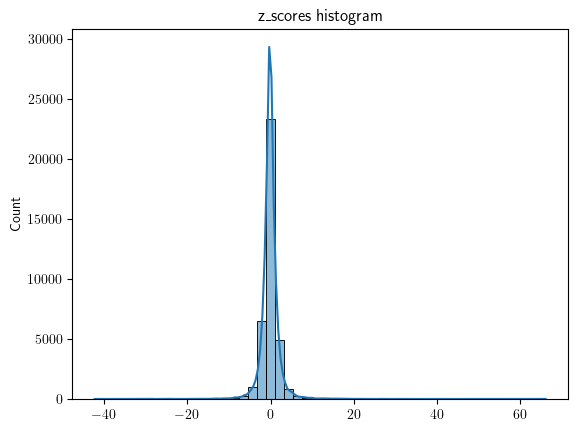

In [1073]:
#| fig-cap: "A histogram of z_scores"

# A histogram
ax = sns.histplot(z_scores_series, kde=True, bins=50, log_scale=0)
ax.set_title('z_scores histogram')
plt.show()

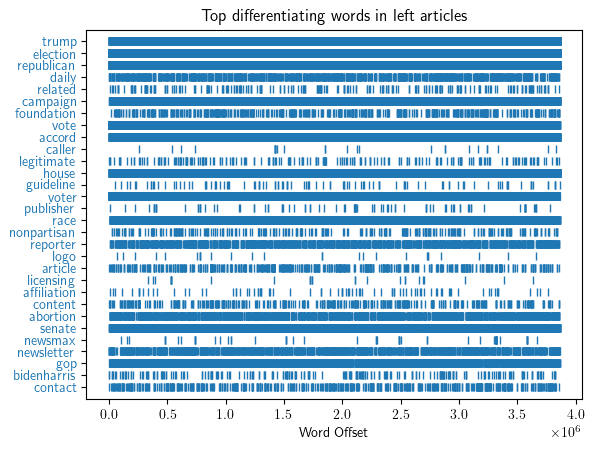

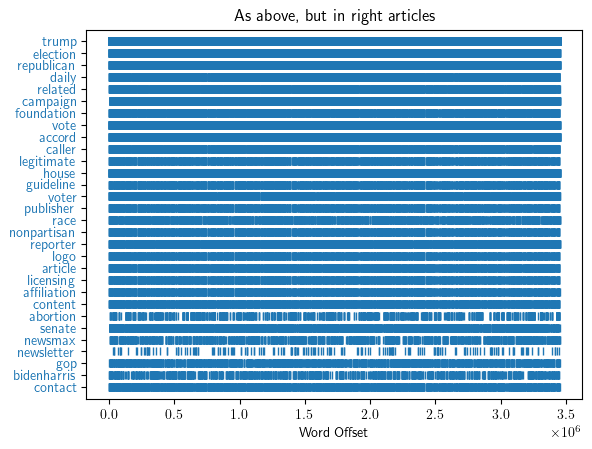

In [1120]:
#| fig-cap: "Inspecting the top words with the highest differentiation strength in left and right articles reveals that the z-scores' differentiation strength may still be influenced by a weak background prior."

pre_text_left = Text(pre for row in preprocessed_left for pre in row)
pre_text_right = Text(pre for row in preprocessed_right for pre in row)

ax = nltk.draw.dispersion_plot(pre_text_left, z_scores_series.index[:30])
ax.set_title('Top differentiating words in left articles')
ax_ = nltk.draw.dispersion_plot(pre_text_right, z_scores_series.index[:30])
ax_.set_title('As above, but in right articles')
plt.show()

In [825]:
# To compute the optimal scaling factor below, 
# we contain the entire LOR-IDP z-score calculation (steps 3-6) in one function
def z_score_scaling(scaling_factor = 0.5):
    """Compute the z-score with scaling."""

    # Vary the dirichlet prior
    alpha_0 = alpha.total() * scaling_factor
    alpha_w = {word: P_bg[word] * alpha_0 for word in alpha}

    # Recalculate delta
    delta_values = {}
    for token in train_tokens: 
        freq_w_i = freq_left.get(token, 0)
        freq_w_j = freq_right.get(token, 0)
        alpha_w_ = alpha_w.get(token, 0)
                
        if freq_w_i and freq_w_j:
            delta_values[token] = delta_w(
                freq_w_i, freq_w_j, n_left, n_right, alpha_w_, alpha_0)

    delta_series = pd.Series(delta_values).sort_values(ascending=False, key=abs)

    z_scores_values = {}
    for token, delta in delta_series.items():
        freq_w_i = freq_left.get(token, 0)
        freq_w_j = freq_right.get(token, 0)
        alpha_w_ = alpha_w.get(token, 0)
        if freq_w_i and freq_w_j:
            z_scores_values[token] = calculate_z_score(delta, freq_w_i,freq_w_j,alpha_w_)

    return pd.Series(z_scores_values).sort_values(key=abs, ascending=False)    

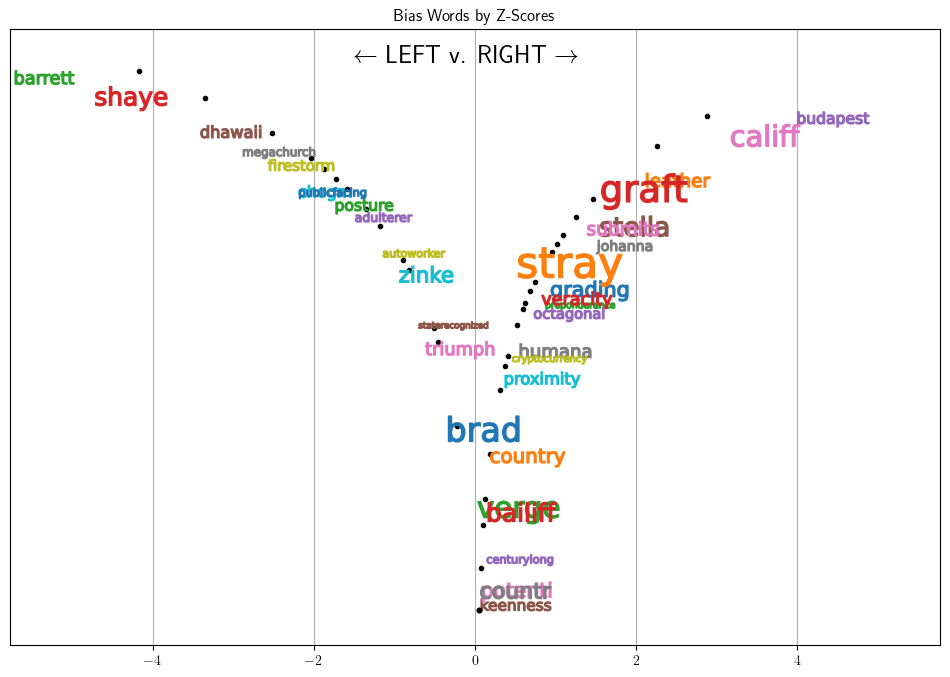

In [ ]:
#| fig-cap: "A random sample of 0.1% of words of to visualise bias words"

# Convert to df and invert the sign for consistency
z_scores_df = z_scores_series.to_frame('d')  

# Visualise ~1% of bias words
plt.figure(figsize=(12,8))
for i, row in enumerate(list(z_scores_df.itertuples())):
    if i % 1000 == 0:

        # Adding some random spread to reduce overlap
        path1 = TextPath((random.normalvariate(0,5), 
                          random.normalvariate(0,5)), row[0])

        # Note the log scale on the y-axis
        # This to compress the extreme values
        plt.plot(row[1], np.log(abs(row[1])), '.',color='k')

        # Adding a horizontal spread on the x-axis, and a log scale on the y
        plt.plot(row[1]*1.4, np.log(abs(row[1])), marker=path1, markersize=100)

plt.xlim(-np.log(max(z_scores_df.d))-2, np.log(max(z_scores_df.d))+2)
plt.ylim(-np.log(max(z_scores_df.d))+0.5, np.log(max(z_scores_df.d))-2)
plt.title('Bias Words by Z-Scores')
plt.gca().get_yaxis().set_visible(False)
plt.grid(visible=True, which='major', axis='x')
plt.text(x=-1.5, y=1.5, s=r'$\leftarrow$  LEFT  v.   RIGHT $\rightarrow$', fontsize=18)
plt.show()

#### Implementing the raw Statistical Method

While intended for feature ranking and selection, the LOR-IDP can also be implemented as a raw statistical tool. We simply compute the sum of z-scores for each sentence in the test set. If the total is positive, we assign 'left', if it's negative we assign 'right'. To compute the accuracy we then take the mean of these assigned labels, or simply use the `accuracy_score` function.

**Classify based on aggregated z-scores:**

In [827]:
def add_z_scores(sent):
    """Compute z-scores per sentence"""
    sent_score = sum(z_scores_series.loc[token] 
                     for token in sent if token in z_scores_series.index)
    return sent_score / len(sent) if len(sent) > 0 else 0

X_test['z_scores'] = X_test.pre_sents.apply(add_z_scores)
X_train['z_scores'] = X_train.pre_sents.apply(add_z_scores)

# Calculate prediction
y_pred = X_test.z_scores.map(lambda score: 'left' if score < 0 else 'right')

accuracy_score(y_test,y_pred)

0.6308049535603715

**Classify based on aggregate delta scores:**

We can equally compute the sum of $ \delta_w^{(i-j)} $ values for each sentence in the test set.

In [ ]:
def add_delta_scores(sent):
    """compute the delta per token for each sentence."""

    sent_score = sum(delta_series.loc[token] 
                     for token in sent if token in delta_series.index)
    return sent_score / len(sent) if len(sent) > 0 else 0

X_test['delta'] = X_test.pre_sents.apply(add_delta_scores)
X_train['delta'] = X_train.pre_sents.apply(add_delta_scores)

# Map the calculation to labels
y_pred = X_test.delta.map(lambda score: 'left' if score < 0 else 'right')

accuracy_score(y_test, y_pred)

0.6940144478844169

### The Feature Extractor

For greater modularity and access to the vocabulary attribute inside each vectoriser, we encapsulate the feature extraction logic in a class. It includes the `DictVectorizer`, the `CountVectorizer` and the `TfidfVectorizer`. The latter two benefit from the ability to set `ngram_range`. This mitigates some of the sideeffects of Naive Bayes' conditional independence assumption. However, due to the feature selection, the number of words in the vocabulary is so small that 2- and 3-word patterns are rare. 

In [1100]:
# For a starting point
n_top_words = 20000

In [830]:
class FeatureExtractor:
    def __init__(self, n_top_words, z_scores_series=z_scores_series):
        """
        Initialise instance by choosing vectorizer type, and
        Preprocess the chosen number of features.
        """
        self._z_scores_series = z_scores_series
        self._voc_list = self._z_scores_series.iloc[:n_top_words].index
        # print('FeatureExtractor is using', len(self._voc_list), 'words')

    def extract_features(self, X_train, X_test):        
        """Extract BOW features."""
        X_train_pre = X_train.pre_sents.apply(lambda tokens: 
                                              {token: 1 for token in tokens 
                                               if token in self._voc_list})
        X_test_pre = X_test.pre_sents.apply(lambda tokens: 
                                            {token: 1 for token in tokens 
                                             if token in self._voc_list})

        self._vectorizer = DictVectorizer()
        X_train_v = self._vectorizer.fit_transform(X_train_pre)
        X_test_v = self._vectorizer.transform(X_test_pre)
        return X_train_v, X_test_v 
    
    def preprocess_and_extract_count_features(self, X_train, X_test):   
        """
        Preprocess and extract BOW features
        with `CountVectorizer`.
        """
        self._vectorizer = CountVectorizer(vocabulary=self._voc_list,
                                tokenizer = apply_preprocessing,
                                token_pattern = None,
                                # ngram_range = (1,3), # For Naive Bayes
                                ) 
        X_train_v = self._vectorizer.fit_transform(X_train.sents)
        X_test_v = self._vectorizer.transform(X_test.sents)
        return X_train_v, X_test_v
    
    def preprocess_and_extract_Tfidf_features(self, X_train, X_test):       
        """
        Preprocess and extract BOW features
        with `TfidfVectorizer`.
        """
        self._vectorizer = TfidfVectorizer(vocabulary=self._voc_list,
                                tokenizer = apply_preprocessing,
                                token_pattern = None,
                                # ngram_range = (1,3), # For Naive Bayes
                                ) 
        X_train_v = self._vectorizer.fit_transform(X_train.sents)
        X_test_v = self._vectorizer.transform(X_test.sents)
        return X_train_v, X_test_v
    
    @property
    def get_vocab(self):
        """Return vocabulary from instance"""
        return self._vectorizer.vocabulary_

In [1101]:
# Preprocess and extract features
vectorizer = FeatureExtractor(n_top_words)
train_vectors, test_vectors = vectorizer.extract_features(X_train, X_test)

# We now have access to:
# vectorizer.get_vocab

### Training the Classifier

We now arrive at the core of our task: training and evaluating the classifiers. Each algorithm is trained using features selected through the LOR-IDP methodology, ensuring a robust and interpretable feature set. To ensure comparability, all classifiers are evaluated on the same test set. Alongside LOR-IDP, we also explore two alternative feature extraction methods: Scikit-learn’s `CountVectorizer` and `TfidfVectorizer`, allowing us to assess the broader applicability of these approaches.

To optimise model performance, a grid search is conducted to fine-tune hyperparameters. This focuses on identifying the optimal number of features (`n_top_words`) to include in the model, ensuring that the feature set is neither too sparse nor overly broad. Additionally, the `scaling_factor` is adjusted to re-rank features as discussed in @monroe2017, striking a balance between the influence of the background corpus and the discriminative power of individual features.

#### Three Classic Models

We evaluate three widely used classifiers from Scikit-learn: `BernoulliNB`, `LogisticRegression`, and `RandomForestClassifier`, each selected for its strengths in text classification.

Naive Bayes (BernoulliNB) serves as our baseline model. Its probabilistic nature makes it simple yet effective for tasks like text classification, especially when paired with binary feature representations. However, its assumption of feature independence may limit its ability to capture complex word relationships, though this can be mitigated through the inclusion of n-grams.

Logistic Regression stands out as a robust linear model for binary classification. Its ability to handle sparse, high-dimensional feature spaces makes it particularly suited for text data. The inclusion of L2 regularisation further mitigates the influence of extreme feature weights, ensuring stability and reliability.

Random Forest is an ensemble method that combines multiple decision trees to improve predictive performance. Its capacity to assess feature importance makes it invaluable for understanding the contributions of individual features. However, its complexity requires careful tuning to avoid overfitting, particularly when applied to sparse datasets like text.

By comparing these models, we aim to understand the relative strengths of each approach and evaluate the impact of LOR-IDP and other feature extraction techniques on classification performance. This comprehensive evaluation ensures that the final results are both meaningful and actionable.

In [1102]:
clf = BernoulliNB()
clf.fit(train_vectors, y_train)
clf.score(test_vectors, y_test)

0.7180082559339526

In [ ]:
LogisticRegression(max_iter = 1000)\
    .fit(train_vectors, y_train).score(test_vectors, y_test)

0.7484520123839009

In [834]:
rf = RandomForestClassifier(
    # max_depth=30, 
    # min_samples_split=5
    n_jobs=-1
                            )
rf.fit(train_vectors, y_train)
rf.score(test_vectors, y_test)

0.7466460268317854

#### Error Analysis

In keeping with the methodology set out in [@bird2009, p. 225], we will now analyse the errors and attempt to retrace them through the feature selection process and mitigate them. We use the Naive Bayes classifier, extract the predicted probabilities, and show them.

In [1108]:
# Showing the biggest classification errors 

def analyse_sorted_errors(y_pred, worst=5, 
                          by_score: Literal['delta', 
                                            'z_scores', 
                                            'pred_proba']='z_scores'
                                            ):
    """Analyse error rate by z-score"""

    X_test['pred'] = y_pred    

    # 'Left' articles predicted as 'Right'
    display(Markdown(f"**{worst} 'Left' articles falsely predicted as 'Right':**"))
    right_but_left = X_test.loc[(X_test.bias == 'left') & (X_test.pred == 'right')]\
        .sort_values(by=by_score, key=abs,ascending=False)
    display(right_but_left[['bias', 'pred', 'title',  by_score, 'num_rating']].head(worst))

    # The key features contribution to misclassification
    display(Markdown("**Top word scores for falsely predicted 'Left' article:**"))
    display(pd.Series({w:z_scores_series[w] for w in right_but_left.pre_sents.iloc[0] if w in z_scores_series})\
            .sort_values(key=abs,ascending=False).head(10))    
    
    # Same for 'Right' articles predicted as 'Left'
    display(Markdown(f"**{worst} 'Right' articles falsely predicted as 'Left':**"))
    left_but_right = X_test.loc[(X_test.bias == 'left') & (X_test.pred == 'right')]\
        .sort_values(by=by_score, key=abs,ascending=False)
    display(left_but_right[['bias', 'pred','title', by_score, 'num_rating']].head(worst))

    # The key features contribution to misclassification
    display(Markdown("**Top word scores for falsely predicted 'Right' article:**"))
    display(pd.Series({w:z_scores_series[w] for w in left_but_right.pre_sents.iloc[0] if w in z_scores_series})\
            .sort_values(key=abs,ascending=False).head(10))
    
# Extracted the predicted probabilities
pred_proba = clf.predict_proba(test_vectors)
X_test['pred_proba'] = [l-r for l,r in pred_proba]    
y_pred = ['left' if np.argmax(proba) == 0 else 'right' for proba in pred_proba]

analyse_sorted_errors(y_pred, 5, by_score='pred_proba')

**5 'Left' articles falsely predicted as 'Right':**

,bias,pred,title,pred_proba,num_rating
9657,left,right,"Elon Musk, Taylor Swift, Antony Blinken, China, and the Idiocy of Tom Friedman",-1.0,-4.0
9635,left,right,Report from Damascus: Relief Mixed with Sadness. Syrians Search for Loved Ones in Prisons & Morgues,-1.0,-4.0
5280,left,right,Biden Is Making a Big Change to Ukraine Strategy Before Trump Takes Office. That's No Accident.,-1.0,-4.0
5336,left,right,The Moment Is Ripe to Push the Middle East in the Direction of Peace. What Will Trump Do?,-1.0,-4.0
1530,left,right,Who is the leader of Syria's rebels and what does he want?,-1.0,-1.3


**Top word scores for falsely predicted 'Left' article:**

trump      66.151071
article   -28.768007
party      21.500262
week       19.236183
china     -18.287785
outlet    -17.792616
without   -17.426342
chinese   -16.850581
drop      -16.808655
care       16.652367
dtype: float64

**5 'Right' articles falsely predicted as 'Left':**

,bias,pred,title,pred_proba,num_rating
9657,left,right,"Elon Musk, Taylor Swift, Antony Blinken, China, and the Idiocy of Tom Friedman",-1.0,-4.0
9635,left,right,Report from Damascus: Relief Mixed with Sadness. Syrians Search for Loved Ones in Prisons & Morgues,-1.0,-4.0
5280,left,right,Biden Is Making a Big Change to Ukraine Strategy Before Trump Takes Office. That's No Accident.,-1.0,-4.0
5336,left,right,The Moment Is Ripe to Push the Middle East in the Direction of Peace. What Will Trump Do?,-1.0,-4.0
1530,left,right,Who is the leader of Syria's rebels and what does he want?,-1.0,-1.3


**Top word scores for falsely predicted 'Right' article:**

trump      66.151071
article   -28.768007
party      21.500262
week       19.236183
china     -18.287785
outlet    -17.792616
without   -17.426342
chinese   -16.850581
drop      -16.808655
care       16.652367
dtype: float64

In [887]:
# Some edge cases
print("'Right' articles predicted as 'left':")
by_score = 'pred_proba'
X_test.loc[(X_test.bias == 'right') & (X_test.pred == 'left')]\
        .sort_values(by=by_score, key=abs,ascending=True)\
                [['title', 'snippet', by_score, 'num_rating']].head(2)

'Right' articles predicted as 'left':


,title,snippet,pred_proba,num_rating
21173,US Appeals Court Upholds TikTok Law Forcing Its Sale,A U.S. federal appeals court on Friday upheld a law requiring Chinese-based ByteDance to divest ...,-0.001902,3.50
9641,John Kerry jets off to China to talk climate again amid questions over plane use,"Special Climate Envoy John Kerry arrived in China Sunday ahead of planned ""in-depth"" talks on cl...",-0.002902,3.88


In [888]:
# Analysing the top edge cases
print("The features that contribute most towards classifying the 'right' article 'left':")
left_cases = pd.Series(
    {w:z_scores_series[w] for w in X_test.loc[(X_test.bias == 'left') & (X_test.pred == 'right')]\
        .sort_values(by=by_score, key=abs,ascending=False)\
            .pre_sents.iloc[0] if w in z_scores_series and z_scores_series[w] < 0})\
            .sort_values(key=abs,ascending=False)
left_cases.head(5)

The features that contribute most towards classifying the 'right' article 'left':


article   -28.768007
china     -18.287785
outlet    -17.792616
without   -17.426342
chinese   -16.850581
dtype: float64

In [1113]:
# Inspect suspicious features in context
all_tokens_ = Text(all_tokens)
all_tokens_.concordance('china', lines=5, width=75)

Displaying 5 of 5154 matches:
stration take first step retaliate china hack biden administration take fir
stration take first step retaliate china broad hack american telecommunicat
ion firm move ban remain operation china telecom united state notice issue 
nited state notice issue last week china telecom america u read trump sue d
vow massive tax good mexico canada china day presidentelect donald trump mo


#### Tf-idf as a Feature Extraction Method

Whereas the LOR-IDP technique scales words with background priors, TF-IDF uses inverse document frequencies. In short, both techniques introduce some kind of feature scaling, ranking and selection. Both have their rationales. This is discussed in detail in @monroe2017, and we will briefly verify what can be assumed analytically. We will see that idf is redundant given that we selected features based on background priors.

In [775]:
# Compare sci-learn's Count and TF-IDF vectorisers
train_vectors, test_vectors = FeatureExtractor(n_top_words)\
    .preprocess_and_extract_Tfidf_features(X_train, X_test)
count_score = BernoulliNB().fit(train_vectors, y_train)\
    .score(test_vectors, y_test)

train_vectors, test_vectors = FeatureExtractor(n_top_words)\
    .preprocess_and_extract_Tfidf_features(X_train, X_test)
tfidf_score = BernoulliNB().fit(train_vectors, y_train)\
    .score(test_vectors, y_test)

print(f"With CountVectorizer the accuracy is {count_score}.",
      f"With TFIDFVectorizer the accuracy is {tfidf_score}.")

With CountVectorizer the accuracy is 0.7174922600619195. With TFIDFVectorizer the accuracy is 0.7174922600619195.


These results indicate that incorporating Tf-idf as an additional regularisation technique has minimal impact on performance. However, a Naive Bayes classifier using a Bag-of-Words (BoW) representation generally benefits from the inclusion of bigrams and trigrams. Although Naive Bayes is limited by its reliance on feature independence, the automatic generation of n-grams is a notable advantage of Scikit-Learn's `CountVectorizer` compared to the more straightforward and faster `DictVectorizer`, which lacks this functionality. This is a consideration worth keeping in mind when balancing efficiency and performance.

#### Optimise the number of features {#sec-optimise}

Training with parameters: [1500, 2500, 3500, 4500, 5500, 6500, 7500, 8500, 9500, 10500, 11500, 12500, 13500, 14500, 15500, 16500]
The best n_top_words is 9500


[]

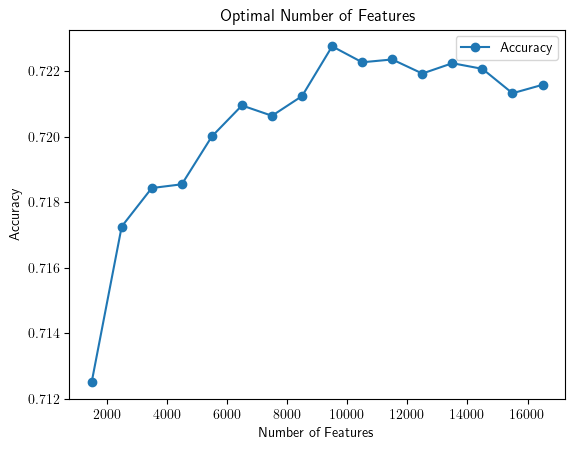

In [788]:
#| fig-cap: "Hyperparameter search: The optimal number of features (bias words)"
#| label: fig-optimal-features

params = range(1500, 17001, 1000)
print("Training with parameters:", list(params))

def optimise_top_words(n_top_words):
    """Determine optimal n_top_words with cross validation"""

    X_train_v, X_test_v = FeatureExtractor(n_top_words, 
                                           z_scores_series=z_scores_series)\
        .extract_features(X_train, X_test) 
    clf = BernoulliNB()
    cv_score = cross_val_score(clf, X_train_v, y_train, cv=5)
    score = np.mean(cv_score)
    return n_top_words, score

with Pool() as p:
    cv_score = p.map(optimise_top_words, params)

cv_score_df = pd.DataFrame(cv_score)
cv_score_df.plot.line(0, 1, marker='o', xlabel='Number of Features', 
                                      ylabel='Accuracy', label='Accuracy',
                                      title='Optimal Number of Features')

n_top_words = max(cv_score, key=lambda x:x[1])[0]
print("The best n_top_words is", n_top_words)

plt.plot()

#### Re-ranking Features Using the `Scaling_Factor`

The `scaling_factor` applied to the background corpus plays a crucial role in adjusting the influence of the prior, as highlighted in [@monroe2017]. Specifically, increasing $\alpha_0$ amplifies the regularising effect of the background corpus, which can significantly impact feature rankings and model performance. In this section, we iterate over a range of `scaling_factor` values to assess their effect on the `accuracy_score` of the classifier. By identifying and selecting the optimal scaling factor, we aim to strike a balance between regularisation and the discriminative power of the features, ultimately enhancing the model's overall performance.

Training with parameters: [0.001, 0.501, 1.001, 1.501, 2.001, 2.501, 3.001, 3.501, 4.001]
The best scaling is 1.501


[]

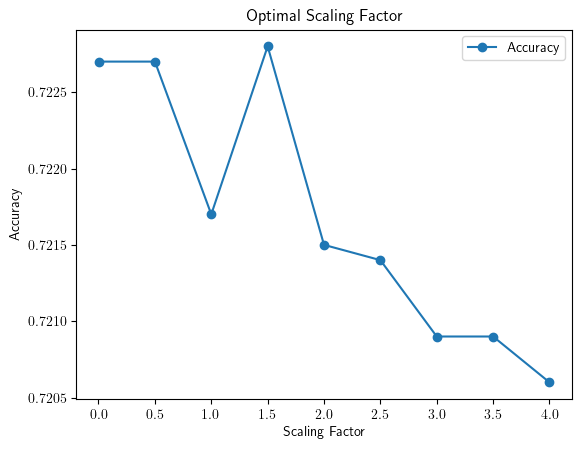

In [802]:
#| fig-cap: "Hyperparameter search: The optimal scaling factor"
#| label: fig-optimal-scaling

params = np.arange(0.001,4.002,0.5)
print("Training with parameters:", list(params))

def optimise_z_scores(scaling_factor):
    """Determine optimally scaled z_scores with cross validation"""

    z_scores_series = z_score_scaling(scaling_factor)
    
    X_train_v, X_test_v = FeatureExtractor(n_top_words, 
                                           z_scores_series=z_scores_series)\
        .extract_features(X_train, X_test) 
    
    clf = BernoulliNB()
    # score = clf.fit(X_train_v, y_train).score(X_test_v, y_test)
    cv_score = cross_val_score(clf, X_train_v, y_train, cv=5) 
    score = np.mean(cv_score)
    return round(scaling_factor,4), round(score,4)

with Pool() as p:
    best_scaling = p.map(optimise_z_scores, params)

pd.DataFrame(best_scaling).sort_index().plot.line(0, 1, 
                                                  marker='o', 
                                                  xlabel='Scaling Factor', 
                                      ylabel='Accuracy', label='Accuracy',
                                      title='Optimal Scaling Factor')

best_scaling = max(best_scaling, key=lambda x:x[1])[0]
print("The best scaling is", best_scaling)
plt.plot()

In [1109]:
n_top_words = 9500
best_scaling = 1.501

In [1094]:
# Recalculate and preprocess with optimal z-scores for best scaling
print(f"Using {n_top_words} top words, and a scaling_factor of {best_scaling}.")
z_scores_series = z_score_scaling(best_scaling)

train_vectors, test_vectors = FeatureExtractor(n_top_words, z_scores_series=z_scores_series)\
    .extract_features(X_train, X_test) 

Using 9500 top words, and a scaling_factor of 1.501.


In [893]:
# Retrain Naive Bayes
clf = BernoulliNB()
clf.fit(train_vectors, y_train)
clf.score(test_vectors, y_test)

0.7154282765737874

In [849]:
# Train Logistic Regression
LogisticRegression(max_iter = 1000)\
    .fit(train_vectors, y_train).score(test_vectors, y_test)

0.750515995872033

In [850]:
# Train Random Forest
rf = RandomForestClassifier(
    # max_depth=20, 
    # min_samples_split=5,
    # n_estimators=200,
    # bootstrap=False,
    n_jobs=-1)
rf.fit(train_vectors, y_train)
rf.score(test_vectors, y_test)

0.7546439628482973

In [1110]:
# Manually, we can get a higher score (see evaluation for in depth analysis)
n_top_words = 2000
best_scaling = 1.5

print(f"Using {n_top_words} top words, and a scaling_factor of {best_scaling}.")

z_scores_series = z_score_scaling(best_scaling)
train_vectors, test_vectors = FeatureExtractor(n_top_words, z_scores_series=z_scores_series)\
    .extract_features(X_train, X_test) 

nb = BernoulliNB()
nb.fit(train_vectors, y_train)
nb_score = nb.score(test_vectors, y_test)
lr = LogisticRegression(max_iter=1000)
lr.fit(train_vectors, y_train)
lr_score = lr.score(test_vectors, y_test)
rf = RandomForestClassifier(n_jobs=-1)
rf.fit(train_vectors, y_train)
rf_score = rf.score(test_vectors, y_test)

print(f"\nThe scores are: \n\t- For Naive Bayes: {round(nb_score, 2)},",
      f"\n\t- For Logistic Regression: {round(lr_score, 2)},",
      f"\n\t- For Random Forest: {round(rf_score, 2)}.")

Using 2000 top words, and a scaling_factor of 1.5.

The scores are: 
	- For Naive Bayes: 0.71, 
	- For Logistic Regression: 0.76, 
	- For Random Forest: 0.75.


### Evaluating Feature Importance  {#sec-feature-importance}

#### Feature Importance in Naive Bayes

To further evaluate our feature selection and ranking, we now move on to two approaches to evaluate feature importance.

First, we utilise a method from `nltk`'s implementation of Naive Bayes. This offers an interesting way to determine the most informative features. However, `nltk`'s `NaiveBayesClassifier` expects a `(featureset, label)` tuple; each featureset is, in turn, a list of `(features, category)` tuples. We thus reimplement the preprocessing, to align with [@bird2009, pp. 227-228].

The steps are the following:

- The feature extractor (`doc_features()`) iterates over each article (preprocessed as `pre_sent`).
- Every word is added as a `feature label`.
- For each label, its `feature values` are set to True or False,
- The feature value corresponds to whether the word is in the selected `n_top_words`.

In [785]:
# Implementing nltk's NaiveBayesClassifier
def doc_features(document):
    doc_words = set(document)
    features = {}
    for word in doc_words:
        if word in z_scores_series.iloc[:n_top_words].index:
            features[word] = word in doc_words
    return features

# Train the classifier
train_docs = list(zip(X_train.pre_sents, y_train))
train_featureset = [(doc_features(d), c) for (d,c) in tqdm(train_docs)]

classifier = nltk.classify.NaiveBayesClassifier.train(train_featureset)

# Test
test_docs = list(zip(X_test.pre_sents, y_test))
test_featureset = [(doc_features(d), c) for (d,c) in tqdm(test_docs)]
print('Accuracy:', nltk.classify.accuracy(classifier, test_featureset))

# Return the most informative features
classifier.show_most_informative_features(5)

  0%|          | 0/34880 [00:00<?, ?it/s]

  0%|          | 0/3876 [00:00<?, ?it/s]

Accuracy: 0.7020123839009288
Most Informative Features
               republish = True            right : left   =    541.8 : 1.0
                  byline = True            right : left   =    344.0 : 1.0
                  caller = True            right : left   =    122.4 : 1.0
               licensing = True            right : left   =    102.6 : 1.0
                    logo = True            right : left   =     74.9 : 1.0


On a previous run we found a number of HTML tags wrongly labelled as `right`. 
These were be considered noise and were removed:  
`['width', 'byline', 'maxwidthpx', 'px', 'marginleft', 'marginright']`

#### Feature importance in Random Forest

Next, we look at the most important features according to random forest.

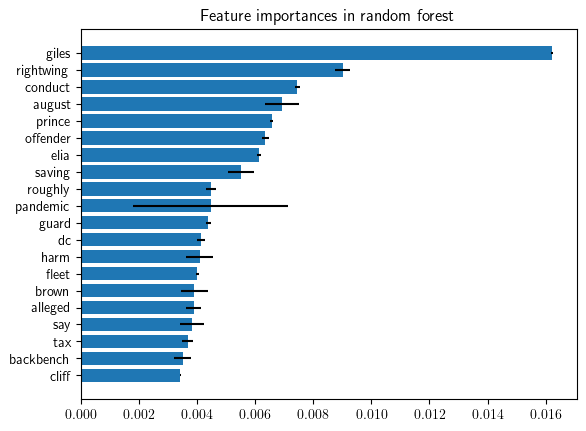

In [852]:
#| fig-cap: "The mean and std feature_importances"

# Plot bar chart with the mean and std feature_importances
max_feat = 20

feature_map = vectorizer.get_vocab
feat = [(name, imp) for name, imp in zip(feature_map, rf.feature_importances_)]
feat = sorted(feat, key=lambda x:x[1], reverse=True)
feats = feat[:max_feat]

plt.barh(
    y=[f[0] for f in feats], 
    width=[f[1] for f in feats],
    xerr=np.std([tree.feature_importances_[:max_feat] for tree in rf.estimators_], axis=0)
    )

plt.gca().invert_yaxis()
plt.title('Feature importances in random forest')
plt.show()

#### Error Analysis (iteration)

Before moving on to the conclusion, we return to our error analysis. We take our best model, LogisticRegression, and start by looking at the probabilities of wrongly predicted articles, along with their highest scoring words in terms of z-scores. 

In [1111]:
print("=> The Accuracy score for Logistic Regression:", round(lr.score(test_vectors, y_test), 3))

pred_proba = lr.predict_proba(test_vectors)
X_test['pred_proba'] = [l-r for l,r in pred_proba]    
y_pred = ['left' if np.argmax(proba) == 0 else 'right' for proba in pred_proba]

analyse_sorted_errors(y_pred, 3, by_score='pred_proba')

=> The Accuracy score for Logistic Regression: 0.761


**3 'Left' articles falsely predicted as 'Right':**

,bias,pred,title,pred_proba,num_rating
6425,left,right,"See how hurricanes have upended presidential politics, from Helene to Sandy to Katrina",-0.992696,-2.0
9343,left,right,GOP congressman whines and makes threats after Hunter Biden pardon,-0.972232,-4.0
9913,left,right,MAGA Lawmakers Call on DeSantis To Appoint Lara Trump to Marco Rubio's Senate Seat,-0.948921,-2.0


**Top word scores for falsely predicted 'Left' article:**

trump         66.151071
election      45.735578
republican    42.324916
house         31.233762
audience     -25.958259
oct          -23.395951
democrat      22.021645
party         21.500262
report       -18.205064
briefing      17.226746
dtype: float64

**3 'Right' articles falsely predicted as 'Left':**

,bias,pred,title,pred_proba,num_rating
6425,left,right,"See how hurricanes have upended presidential politics, from Helene to Sandy to Katrina",-0.992696,-2.0
9343,left,right,GOP congressman whines and makes threats after Hunter Biden pardon,-0.972232,-4.0
9913,left,right,MAGA Lawmakers Call on DeSantis To Appoint Lara Trump to Marco Rubio's Senate Seat,-0.948921,-2.0


**Top word scores for falsely predicted 'Right' article:**

trump         66.151071
election      45.735578
republican    42.324916
house         31.233762
audience     -25.958259
oct          -23.395951
democrat      22.021645
party         21.500262
report       -18.205064
briefing      17.226746
dtype: float64

**Note:** The overlap in top words for both classes of misclassified articles suggests that the background corpus lacks data on election-related features. Specifically, low counts of terms like 'trump' and 'election' in the prior led to these words being assigned disproportionately high differentiation strength in their z-scores.


------------------------------------------------------------------------

# Conclusions 

## Evaluation 

The final performance of the three classifiers was evaluated on the dataset, with logistic regression emerging as the best-performing model. It delivered a **5 percentage point** improvement in accuracy over the baseline model, successfully achieving a core objective of this project. Additionally, it demonstrated a gain of 5–11% compared to a comparable baseline reported in @hajare.

Logistic regression’s superior performance highlights its suitability for this type of task. As a discriminative model, it is highly effective in sparse, high-dimensional feature spaces, which are characteristic of text classification problems. This robustness, coupled with its ability to handle binary classification tasks with precision, underscores why it excelled in distinguishing political bias in news content. The results reinforce the model’s reliability and validate its effectiveness in leveraging the LOR-IDP features for accurate predictions.

### Overview

In terms of accuracy, we accumulated the following values:

| Model                      | Accuracy            |
|----------------------------|---------------------|
| NaiveBayes Baseline        | 0.7159442724458205  |
| Z-score                    | 0.6308049535603715 |
| Delta values               | 0.6940144478844169  |
| NaiveBayes                 | 0.7180082559339526    |
| nltk NaiveBayes | 0.7094943240454077|
| LogisticRegression | 0.7484520123839009 |
| RandomForest | 0.7466460268317854|
| NaiveBayes with hyper params | 0.7154282765737874|
| LogisticRegression with hyper params  | 0.7613519091847265 |
| RandomForest with hyper params  | 0.7603199174406605|

The best values used 2000 features, and a scaling_factor of 1.5. Notably, Naive Bayes improve little over the baseline.

### Detailed Classification Report

While the aggregated delta-values and z-scores are decent predictors compared to the non-ML baseline, the best Machine Learning algorithm added nearly 7 percentage points. We can now compare the precision, recall, and f1-score alongside these with a classification report: 

In [1044]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

        left       0.83      0.74      0.79      2286
       right       0.68      0.79      0.73      1590

    accuracy                           0.76      3876
   macro avg       0.76      0.77      0.76      3876
weighted avg       0.77      0.76      0.76      3876



**Key Insight:** The test set exhibits a significant class imbalance between 'left' and 'right' labels, which may explain the notably higher precision for 'left' labels. As seen in the summary statistics in @sec-summary-stats, the dataset as a whole did not indicate this kind of imbalance. 

The observed 15% gap in precision indicates a high rate of False Positives among 'right' predictions. This trade-off between False Negatives and False Positives is best visualised using a confusion matrix. As shown below, the primary issue lies with the top-right value, representing false 'right' predictions. 

Addressing the imbalance could involve increasing the test size (currently only 10%), changing the seed (the `random_state` parameter), under- or oversampling, or collecting additional data to provide a more representative distribution.

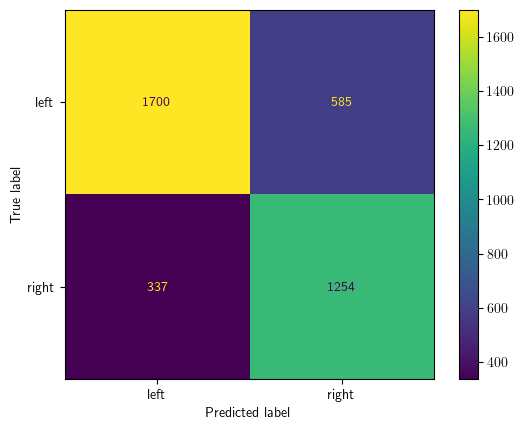

In [672]:
ConfusionMatrixDisplay.from_predictions(y_pred, y_test, cmap='viridis')
plt.show()

### Generalisability in terms of Transfer Learning

Finally, we assess the generalisability of our primarily American dataset by evaluating its applicability to UK publications, exploring the potential for transfer learning.

While The Telegraph and The Daily Mail are occasionally misclassified as 'left', other UK publications are mostly predicted correctly. However, the low sample counts for these publications limit the reliability of these evaluations, underscoring the need for more representative data to draw robust conclusions.

In [1037]:
uk_sources = ['spectator.org', 'theguardian.com', 'vice.com', 'telegraph.co.uk', 'independent.co.uk', 'dailymail.co.uk',  'economist.com']

uk_sources_s = X_test.query("@uk_sources in source_api")
print("The test accuracy on UK papers is:", 
      (uk_sources_s['bias'] == uk_sources_s['pred']).mean().round(3))

uk_series = uk_sources_s.source_api.value_counts()
uk_biases = uk_sources_s.groupby('source_api')[['bias']].first()
mean_proba = uk_sources_s.groupby('source_api')['pred_proba'].mean()

pd.concat([uk_series, uk_biases, mean_proba], axis=1).round(2)

The test accuracy on UK papers is: 0.647


,count,bias,pred_proba
source_api,,,
independent.co.uk,66,left,-0.75
theguardian.com,61,left,-0.71
telegraph.co.uk,48,right,-0.76
spectator.org,19,right,0.42
dailymail.co.uk,9,right,-0.57
vice.com,3,left,0.09
economist.com,1,left,-0.99


## Summary and Conclusions

This project demonstrated the efficacy of the Log Odds Ratio Informative Dirichlet Prior (LOR-IDP) in feature selection and weighting for political bias classification. By integrating background knowledge through a Dirichlet prior, LOR-IDP effectively reduced sparsity in the dataset and improved class separability, resulting in interpretable features that enhance both model transparency and human understanding.

The comparative analysis of Naive Bayes, Logistic Regression, and Random Forest revealed distinct strengths and weaknesses. Logistic Regression emerged as the most robust, excelling in sparse, high-dimensional feature spaces due to its effective L2 regularisation. However, its reliance on linear separability posed limitations for non-linear decision boundaries. Naive Bayes underperformed, largely because of its strong independence assumptions, though incorporating n-grams to capture word co-occurrence holds promise for improvement. Random Forest showed potential in identifying feature importance but struggled with sparsity, requiring careful hyperparameter tuning for optimal performance.

Initial results using the AllSides dataset yielded only marginal improvements over baseline accuracy. Early iterations made a key assumption: that the dataset's carefully curated, side-by-side comparisons would provide sufficient semantics for the model to learn meaningful patterns. This proved mistaken. While temporal diversity in the data, ranging from 2022 to the present, added robustness, class imbalance (60% left-leaning versus 40% right-leaning labels) and accuracy stagnating at around 62% highlighted the need for additional data sources.

The integration of the NewsCatcher API data addressed these issues and significantly improved performance, but not without challenges. For instance, the background corpus underrepresented election-related language, necessitating adjustments to the Dirichlet prior's scaling factor ($\alpha_0$). Additionally, feature optimisation revealed unexpected trends: while the larger dataset converged on a higher feature count (around 11,500), the best performance was achieved with only 2,000 features, indicating asymmetries in the feature space due to the shorter article lengths of the AllSides data. 

Interestingly, the polarised language used during the U.S. election may have artificially boosted classifier performance. It is unfortunate but it may also explain why the model may fail to generalise to UK publications, as many politicians and commentators here remain wary of echooing overly divisive ideas.

### Future Directions

While binary classification provides a strong starting point, future work can explore multi-class labelling to capture a broader spectrum of political orientations, such as extreme, moderate, centre-left, centre, and so on. Starting from UK-only datasets, including UK-specific sources, could also enhance the model's adaptability to other cultural and political contexts. Further advancements could leverage contextual embeddings, such as XLM-RoBERTa or GloVe, to enable cross-linguistic generalisation and better representation of nuanced language. 

Finally, this project's methodology offers promising applications in media recommendation systems. By balancing news exposure to include diverse perspectives, such systems could help counteract echo chambers and foster more informed public discourse. 
By addressing key challenges and emphasising both interpretability and scalability, this project hopes to make a meaningful contribution to the study of political bias, natural language processing, and societal discourse.
